<a href="https://colab.research.google.com/github/Kalana-Lakshan/ML-Self-Learning/blob/main/ML_Hackathon_Practise1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [71]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.metrics import mean_squared_error,r2_score
from xgboost import XGBClassifier
from xgboost import XGBRegressor

In [72]:
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

In [73]:
num_cols_train = train_data.select_dtypes(include = np.number).columns

In [74]:
num_cols_train

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

In [75]:
cat_cols_train = train_data.select_dtypes(include = 'object').columns

In [76]:
cat_cols_train

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [77]:
num_cols_test = test_data.select_dtypes(include = np.number).columns
cat_cols_test = test_data.select_dtypes(include = 'object').columns

In [78]:
train_data[num_cols_train] = train_data[num_cols_train].fillna(train_data[num_cols_train].median())

In [79]:
train_data[cat_cols_train] = train_data[cat_cols_train].fillna('unknown')

In [80]:
test_data[num_cols_test] = test_data[num_cols_test].fillna(test_data[num_cols_test].median())
test_data[cat_cols_test] = test_data[cat_cols_test].fillna('unknown')

In [81]:
#num_cols_train == num_cols_test

In [82]:
cat_cols_train == cat_cols_test

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True])

In [83]:
encoder = LabelEncoder()
for col in cat_cols_train:
  train_data[col] = encoder.fit_transform(train_data[col].astype(str))
  test_data[col] = encoder.fit_transform(test_data[col].astype(str))

In [84]:
train_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,3,65.0,8450,1,2,3,3,0,...,0,3,4,4,0,2,2008,8,4,208500
1,2,20,3,80.0,9600,1,2,3,3,0,...,0,3,4,4,0,5,2007,8,4,181500
2,3,60,3,68.0,11250,1,2,0,3,0,...,0,3,4,4,0,9,2008,8,4,223500
3,4,70,3,60.0,9550,1,2,0,3,0,...,0,3,4,4,0,2,2006,8,0,140000
4,5,60,3,84.0,14260,1,2,0,3,0,...,0,3,4,4,0,12,2008,8,4,250000


In [85]:
X = train_data.drop(train_data.columns[-1],axis = 1)
y = train_data[train_data.columns[-1]]

In [86]:
X

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,3,65.0,8450,1,2,3,3,0,...,0,0,3,4,4,0,2,2008,8,4
1,2,20,3,80.0,9600,1,2,3,3,0,...,0,0,3,4,4,0,5,2007,8,4
2,3,60,3,68.0,11250,1,2,0,3,0,...,0,0,3,4,4,0,9,2008,8,4
3,4,70,3,60.0,9550,1,2,0,3,0,...,0,0,3,4,4,0,2,2006,8,0
4,5,60,3,84.0,14260,1,2,0,3,0,...,0,0,3,4,4,0,12,2008,8,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,3,62.0,7917,1,2,3,3,0,...,0,0,3,4,4,0,8,2007,8,4
1456,1457,20,3,85.0,13175,1,2,3,3,0,...,0,0,3,2,4,0,2,2010,8,4
1457,1458,70,3,66.0,9042,1,2,3,3,0,...,0,0,3,0,2,2500,5,2010,8,4
1458,1459,20,3,68.0,9717,1,2,3,3,0,...,0,0,3,4,4,0,4,2010,8,4


In [87]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [90]:
model = XGBRegressor(
    n_estimators = 100,
    max_depth = 5,
    learning_rate = 0.1,
    random_state = 42
)
model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [91]:
y_predict = model.predict(X_test)

In [92]:
print("mse",mean_squared_error(y_test,y_predict))
print("r2",r2_score(y_test,y_predict))

mse 640225984.0
r2 0.9165320992469788


<BarContainer object of 80 artists>

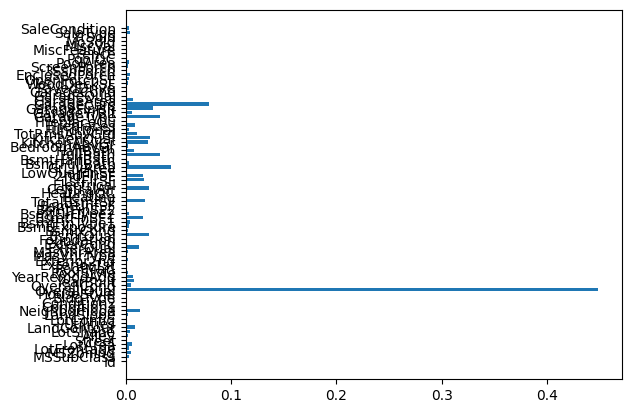

In [93]:
plt.barh(X.columns,model.feature_importances_)

In [94]:
sample_data = pd.read_csv('sample_submission.csv')

In [95]:
sample_data.head()

,Id,SalePrice
0,1461,169277.052498
1,1462,187758.393989
2,1463,183583.683570
3,1464,179317.477511
4,1465,150730.079977


In [96]:
y_predict

array([140944.08 , 346998.94 , 106939.305, 173263.88 , 321617.94 ,
        78466.53 , 230248.62 , 150139.3  ,  81723.49 , 130043.54 ,
       148810.55 , 124135.664, 108354.1  , 203531.77 , 169664.8  ,
       134584.28 , 197165.83 , 138867.86 , 111264.516, 201020.08 ,
       149082.53 , 237992.34 , 172244.52 , 127461.44 , 197099.89 ,
       171706.88 , 195953.22 , 103626.3  , 172095.3  , 190825.05 ,
       122883.766, 245608.73 , 197920.31 , 119188.56 , 253796.77 ,
       149826.64 , 115617.96 , 206442.14 , 311167.38 , 105236.99 ,
       126039.09 , 238512.14 , 117538.445, 375436.3  , 128161.31 ,
       133037.69 , 113341.11 , 130693.42 , 441384.53 , 146719.5  ,
       125010.555, 191622.53 , 112110.53 , 364449.03 , 140722.31 ,
       247027.94 , 195988.73 , 156309.69 , 138797.42 , 104109.82 ,
        72252.   , 157724.4  , 317494.88 , 284390.5  , 245000.23 ,
       232702.98 , 114395.97 , 330677.84 , 118008.625, 162119.61 ,
       125492.31 , 125560.17 , 115762.54 ,  86548.85 , 496769.

In [97]:
y_predictions = model.predict(test_data)

In [102]:
submission = pd.DataFrame({'Id':test_data.Id,'SalePrice':y_predictions})
submission.to_csv('submission_latest.csv',index = False)

In [103]:
pd.read_csv('submission_latest.csv').head()

,Id,SalePrice
0,1461,127367.96
1,1462,162826.81
2,1463,181661.77
3,1464,188326.66
4,1465,191572.88
